# Классификация изображений с использованием Transfer Learning (MobileNetV2)

Лабораторная работа: распознавание марок автомобилей по фотографии.

**Модель:** MobileNetV2 (предобученная на ImageNet) + дообучение головы + fine-tuning.

## 1. Импорт библиотек

In [1]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from IPython.display import clear_output
import visualkeras
from collections import defaultdict
from PIL import ImageFont

## 2. Загрузка и разделение датасета

Разделение: **80% Train / 10% Val / 10% Test**

Используется датасет с изображениями автомобилей по маркам.

In [2]:
# Укажи путь к своему датасету
data_dir = pathlib.Path(r"D:\DATASET")

# Автоматический спуск в нужную папку, если указана родительская
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
if len(classes) == 1:
    data_dir = data_dir / classes[0]

batch_size = 32
img_height = 224  # MobileNetV2 оптимально работает с 224x224
img_width  = 224

# Train выборка (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training", seed=123,
    image_size=(img_height, img_width), batch_size=batch_size)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Названия классов: {class_names}")
print(f"Количество классов: {num_classes}")

# Val + Test выборка (20% -> делим пополам)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=(img_height, img_width), batch_size=batch_size)

val_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds  = val_test_ds.take(val_batches // 2)
test_ds = val_test_ds.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 4965 files belonging to 5 classes.
Using 3972 files for training.
Названия классов: ['BMW', 'Chevrolet', 'Hundai', 'Mercedes-Benz', 'Toyota']
Количество классов: 5
Found 4965 files belonging to 5 classes.
Using 993 files for validation.


## 3. Аугментация данных

Применяем случайные преобразования для увеличения разнообразия обучающей выборки.

In [3]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

### Демонстрация аугментации

Демонстрация работы Data Augmentation (Аугментации данных)



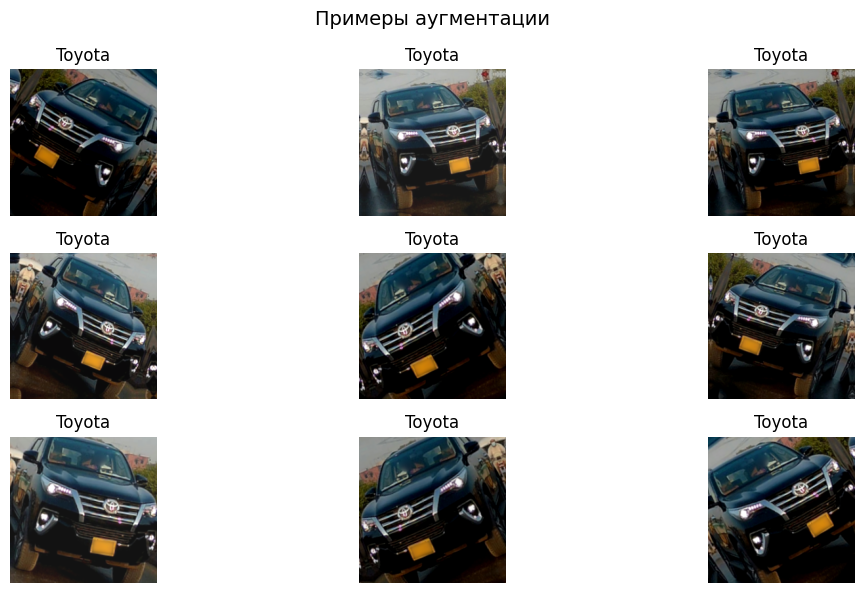

In [4]:
print("Демонстрация работы Data Augmentation (Аугментации данных)\n")

plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(9):
        augmented = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented[0].numpy().astype("uint8"))
        plt.title(class_names[labels[0]])
        plt.axis("off")
plt.suptitle("Примеры аугментации", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Просмотр примеров из датасета

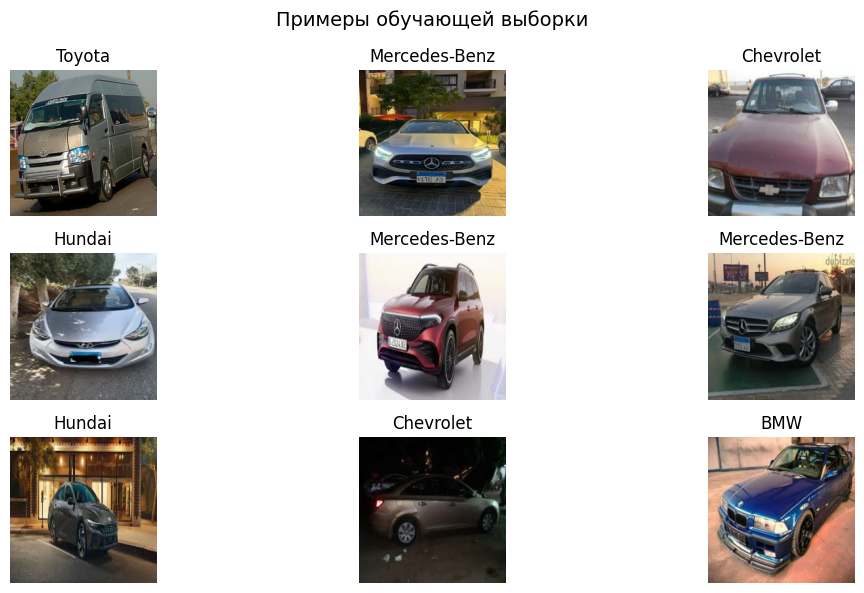

In [6]:
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Примеры обучающей выборки", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Построение модели: Transfer Learning (MobileNetV2)

**Этапы:**
1. Загружаем MobileNetV2 с весами ImageNet, без верхней части (`include_top=False`).
2. Замораживаем все слои backbone — обучаем только голову классификатора.
3. После стабилизации — размораживаем верхние 25% слоёв и делаем fine-tuning.

In [7]:
IMG_SHAPE = (img_height, img_width, 3)

# Загрузка предобученного backbone
base_model = MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # заморозка на этапе 1

print(f"Всего слоёв в MobileNetV2: {len(base_model.layers)}")
print(f"Обучаемых параметров backbone: {base_model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Всего слоёв в MobileNetV2: 154
Обучаемых параметров backbone: 2,257,984


In [8]:
# Построение полной модели
inputs = tf.keras.Input(shape=IMG_SHAPE, name="input_layer")

# Аугментация (только при обучении)
x = data_augmentation(inputs)

# Препроцессинг для MobileNetV2: масштабирование в [-1, 1]
x = preprocess_input(x)

# Backbone — извлечение признаков
x = base_model(x, training=False)

# Голова классификатора
x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = tf.keras.layers.Dropout(0.3, name="dropout_1")(x)
x = tf.keras.layers.Dense(256, activation='relu', name="dense_256")(x)
x = tf.keras.layers.Dropout(0.3, name="dropout_2")(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name="output_layer")(x)

model = tf.keras.Model(inputs, outputs, name="MobileNetV2_CarClassifier")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "MobileNetV2_CarClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_avg_pool                      │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_256 (Dense)                    │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Визуализация архитектуры модели

## 7. Этап 1: Обучение головы классификатора

Backbone заморожен. Обучаем только добавленные слои.

In [16]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_mobilenet_head.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print(f"\nЛучшая val_accuracy (голова): {max(history_head.history['val_accuracy']):.4f}")

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.4400 - loss: 1.3857
Epoch 1: val_loss improved from None to 0.89541, saving model to best_mobilenet_head.keras

Epoch 1: finished saving model to best_mobilenet_head.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 84s 634ms/step - accuracy: 0.5164 - loss: 1.1954 - val_accuracy: 0.6328 - val_loss: 0.8954 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.6303 - loss: 0.9350
Epoch 2: val_loss improved from 0.89541 to 0.87155, saving model to best_mobilenet_head.keras

Epoch 2: finished saving model to best_mobilenet_head.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 629ms/step - accuracy: 0.6279 - loss: 0.9254 - val_accuracy: 0.6621 - val_loss: 0.8715 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.6732 - loss: 0.8322
Epoch 3: val_loss improved from 0.87155 to 0.82081, saving model to best_mobilenet_head.keras

Epoch 3: finished saving model to best_mobilen

### График обучения (голова)

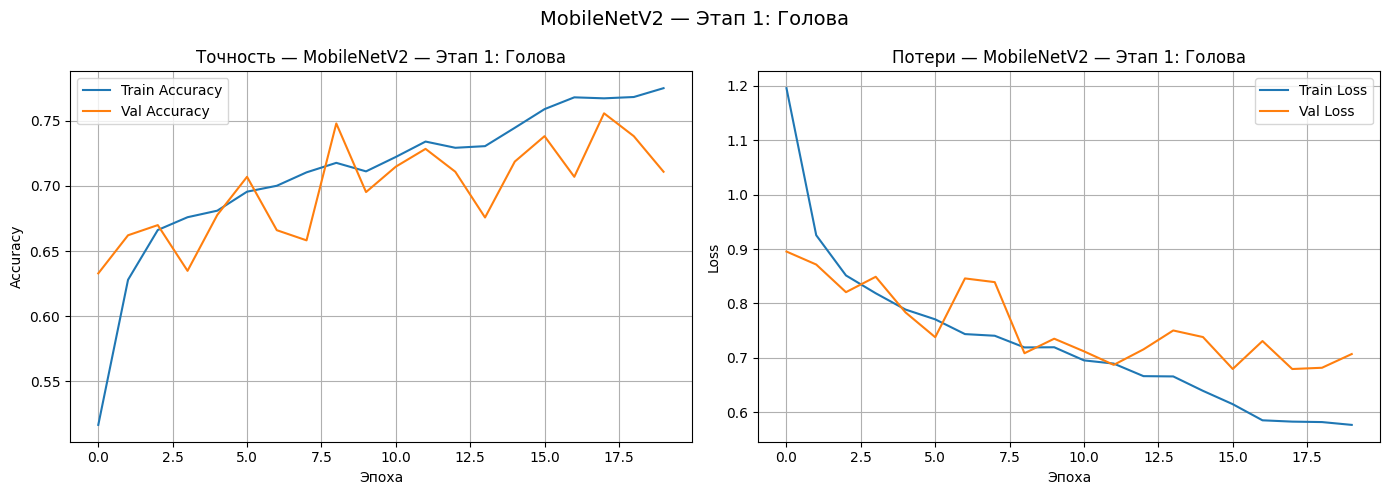

In [17]:
def plot_history(history, title=''):
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']
    epochs_range = range(len(acc))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, acc, label='Train Accuracy')
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy')
    axes[0].set_title(f'Точность — {title}')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs_range, loss, label='Train Loss')
    axes[1].plot(epochs_range, val_loss, label='Val Loss')
    axes[1].set_title(f'Потери — {title}')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_history(history_head, title='MobileNetV2 — Этап 1: Голова')

## 8. Этап 2: Fine-tuning (размораживание верхних слоёв backbone)

Размораживаем верхние **25% слоёв** MobileNetV2 и дообучаем с малым learning rate.

In [26]:
# Размораживаем верхние 25% слоёв backbone
fine_tune_at = int(len(base_model.layers) * 0.75)

base_model.trainable = True
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Размораживаем слои с {fine_tune_at} по {len(base_model.layers)}")
print(f"Обучаемых параметров после размораживания: "
      f"{sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # малый LR для fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_ft = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_ft = tf.keras.callbacks.ModelCheckpoint(
    'best_mobilenet_finetuned.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr_ft = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop_ft, checkpoint_ft, reduce_lr_ft],
    verbose=1
)

print(f"\nЛучшая val_accuracy (fine-tuning): {max(history_ft.history['val_accuracy']):.4f}")

Размораживаем слои с 115 по 154
Обучаемых параметров после размораживания: 2,010,565
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.9587 - loss: 0.1152
Epoch 1: val_loss improved from None to 0.66906, saving model to best_mobilenet_finetuned.keras

Epoch 1: finished saving model to best_mobilenet_finetuned.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 110s 813ms/step - accuracy: 0.9595 - loss: 0.1087 - val_accuracy: 0.8418 - val_loss: 0.6691 - learning_rate: 1.0000e-04
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.9637 - loss: 0.1017
Epoch 2: val_loss improved from 0.66906 to 0.63726, saving model to best_mobilenet_finetuned.keras

Epoch 2: finished saving model to best_mobilenet_finetuned.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 101s 806ms/step - accuracy: 0.9635 - loss: 0.1055 - val_accuracy: 0.8379 - val_loss: 0.6373 - learning_rate: 1.0000e-04
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.9686 - loss: 0.0865
Epoch 3: val_loss improved

### График обучения (fine-tuning)

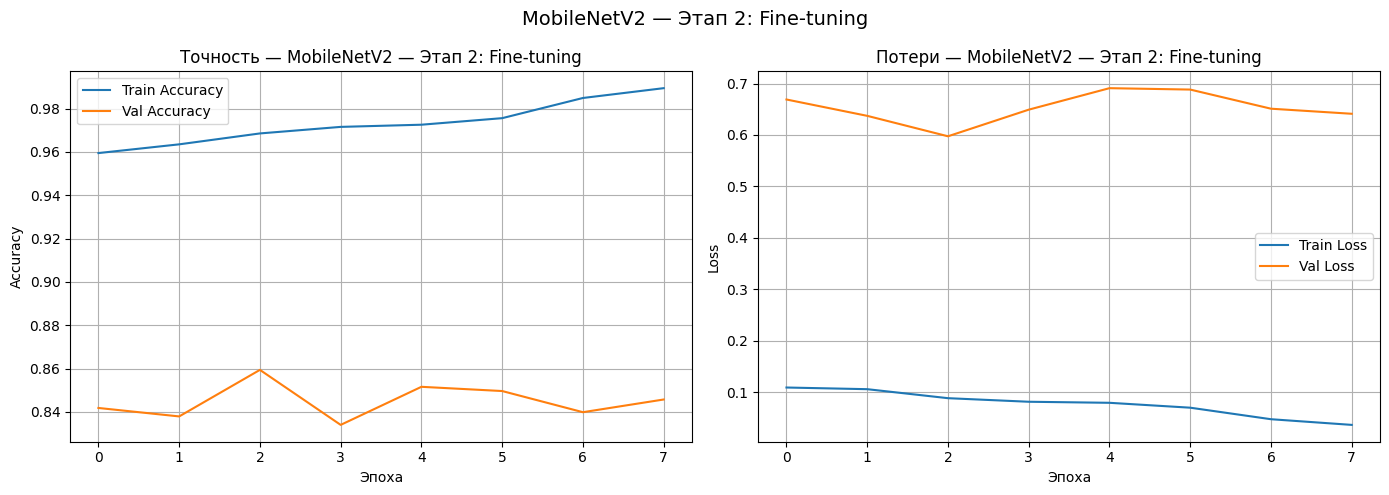

In [27]:
plot_history(history_ft, title='MobileNetV2 — Этап 2: Fine-tuning')

### Объединённый график: все эпохи

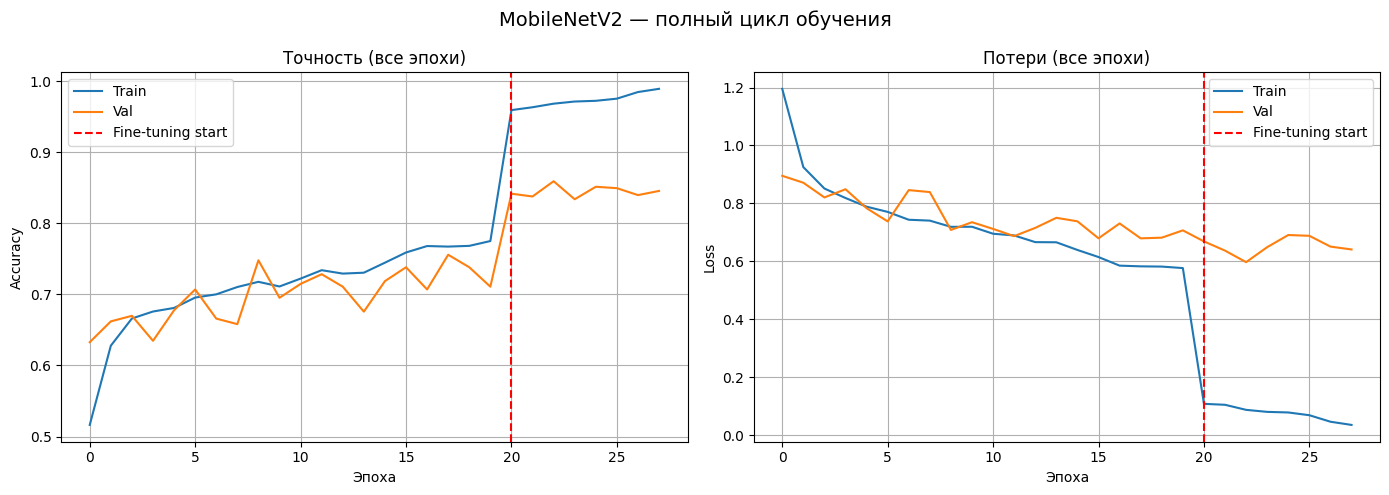

In [28]:
acc_all     = history_head.history['accuracy']     + history_ft.history['accuracy']
val_acc_all = history_head.history['val_accuracy'] + history_ft.history['val_accuracy']
loss_all    = history_head.history['loss']         + history_ft.history['loss']
val_loss_all= history_head.history['val_loss']     + history_ft.history['val_loss']

epochs_all = range(len(acc_all))
ft_start   = len(history_head.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_all, acc_all,     label='Train')
axes[0].plot(epochs_all, val_acc_all, label='Val')
axes[0].axvline(x=ft_start, color='red', linestyle='--', label='Fine-tuning start')
axes[0].set_title('Точность (все эпохи)')
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_all, loss_all,     label='Train')
axes[1].plot(epochs_all, val_loss_all, label='Val')
axes[1].axvline(x=ft_start, color='red', linestyle='--', label='Fine-tuning start')
axes[1].set_title('Потери (все эпохи)')
axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('MobileNetV2 — полный цикл обучения', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Оценка модели на тестовой выборке

In [29]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 470ms/step - accuracy: 0.8753 - loss: 0.4864

Test Loss:     0.4864
Test Accuracy: 0.8753


## 10. Матрица ошибок (Confusion Matrix)

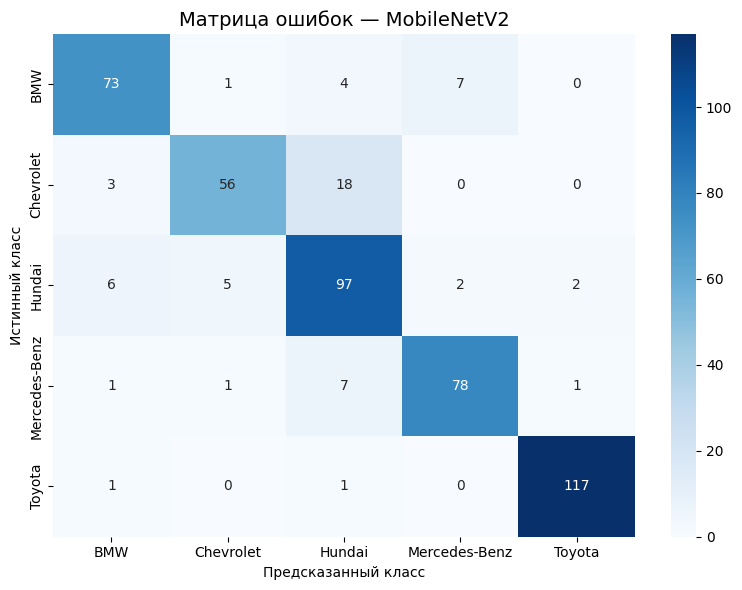

In [30]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)
plt.title('Матрица ошибок — MobileNetV2', fontsize=14)
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

## 11. Отчёт по классификации

In [31]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:

               precision    recall  f1-score   support

          BMW       0.87      0.86      0.86        85
    Chevrolet       0.89      0.73      0.80        77
       Hundai       0.76      0.87      0.81       112
Mercedes-Benz       0.90      0.89      0.89        88
       Toyota       0.97      0.98      0.98       119

     accuracy                           0.88       481
    macro avg       0.88      0.86      0.87       481
 weighted avg       0.88      0.88      0.88       481



## 12. Примеры предсказаний на тестовых изображениях

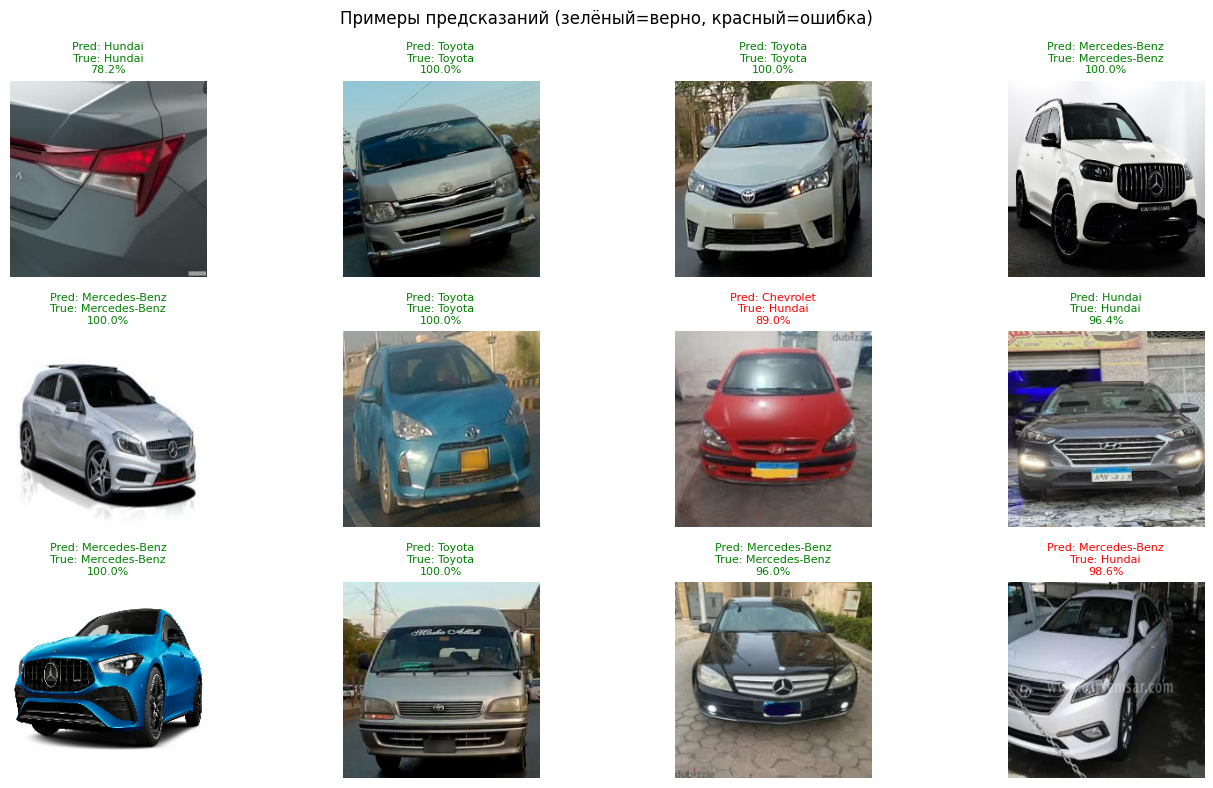

In [32]:
plt.figure(figsize=(14, 8))
for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0)
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        pred_class = class_names[np.argmax(preds[i])]
        true_class = class_names[labels[i]]
        conf       = np.max(preds[i]) * 100
        color = 'green' if pred_class == true_class else 'red'
        plt.title(f"Pred: {pred_class}\nTrue: {true_class}\n{conf:.1f}%",
                  color=color, fontsize=8)
        plt.axis('off')
plt.suptitle('Примеры предсказаний (зелёный=верно, красный=ошибка)', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Сохранение финальной модели

In [33]:
model.save('mobilenet_cars_final.keras')
print("Модель сохранена: mobilenet_cars_final.keras")

# Сводка результатов
print("\n" + "="*50)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*50)
print(f"Лучшая val_accuracy (голова):      {max(history_head.history['val_accuracy']):.4f}")
print(f"Лучшая val_accuracy (fine-tuning): {max(history_ft.history['val_accuracy']):.4f}")
print(f"Test Accuracy (финальная):         {test_acc:.4f}")
print(f"Test Loss:                         {test_loss:.4f}")

Модель сохранена: mobilenet_cars_final.keras

ИТОГОВЫЕ РЕЗУЛЬТАТЫ
Лучшая val_accuracy (голова):      0.7559
Лучшая val_accuracy (fine-tuning): 0.8594
Test Accuracy (финальная):         0.8753
Test Loss:                         0.4864
